# Tablas e imagenes para la comparacion final

Este notebook arma las tablas e imagenes del reporte final usando los **resumenes ya generados** para gradiente y heuristicas.

La comparacion se hace **dentro del mismo caso** (`funcion + dimension`), no entre funciones distintas.

In [215]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")

In [216]:
def find_workspace_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "trabajo_carlos").exists():
            return candidate
    raise FileNotFoundError("No se pudo ubicar la carpeta trabajo_carlos desde el directorio actual.")


ROOT = find_workspace_root()
DATA_ROOT = ROOT / "trabajo_carlos" / "1. optimizacion_numerica"
OUTPUT_DIR = ROOT / "trabajo_carlos" / "blog" / "notebooks" / "numerica" / "salidas_tablas_comparacion_final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ROOT, DATA_ROOT, OUTPUT_DIR

(WindowsPath('C:/Carlos/Uni/Algortimos/trabajos/trabajo_1'),
 WindowsPath('C:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica'),
 WindowsPath('C:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/blog/notebooks/numerica/salidas_tablas_comparacion_final'))

In [217]:
N_OBJETIVO = 1000
METODOS_ORDEN = [
    "Descenso por gradiente",
    "Algoritmo evolutivo",
    "PSO",
    "Evolucion diferencial",
]

COLUMNAS_BASE = [
    "funcion",
    "nombre_funcion",
    "metodo",
    "nombre_metodo",
    "dimension",
    "n_corridas",
    "mejor_valor",
    "peor_valor",
    "promedio_valor",
    "mediana_valor",
    "desviacion_valor",
    "promedio_evaluaciones",
    "mediana_evaluaciones",
    "promedio_iteraciones",
    "mediana_iteraciones",
]

In [218]:
def cargar_resumenes_gradiente() -> pd.DataFrame:
    files = sorted((DATA_ROOT / "gradiente" / "datos").glob("*/resumen_*.csv"))
    if not files:
        raise FileNotFoundError("No se encontraron resumenes de gradiente.")

    frames = [pd.read_csv(path) for path in files]
    df = pd.concat(frames, ignore_index=True)
    df = df.rename(
        columns={
            "mejor_valor_final": "mejor_valor",
            "peor_valor_final": "peor_valor",
            "promedio_valor_final": "promedio_valor",
            "mediana_valor_final": "mediana_valor",
            "desviacion_valor_final": "desviacion_valor",
        }
    )
    df["nombre_metodo"] = "Descenso por gradiente"
    return df[COLUMNAS_BASE].copy()


def cargar_resumenes_heuristicos() -> pd.DataFrame:
    files = sorted((DATA_ROOT / "heuristicos" / "datos").glob("*/resumen_*.csv"))
    if not files:
        raise FileNotFoundError("No se encontraron resumenes heuristicas.")

    frames = [pd.read_csv(path) for path in files]
    df = pd.concat(frames, ignore_index=True)
    return df[COLUMNAS_BASE].copy()


def cargar_comparacion() -> pd.DataFrame:
    grad = cargar_resumenes_gradiente()
    heur = cargar_resumenes_heuristicos()
    df = pd.concat([grad, heur], ignore_index=True)

    for column in [
        "dimension",
        "n_corridas",
        "mejor_valor",
        "peor_valor",
        "promedio_valor",
        "mediana_valor",
        "desviacion_valor",
        "promedio_evaluaciones",
        "mediana_evaluaciones",
        "promedio_iteraciones",
        "mediana_iteraciones",
    ]:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df = df.dropna(subset=["dimension", "n_corridas", "promedio_valor", "promedio_evaluaciones"]).copy()
    df["dimension"] = df["dimension"].astype(int)
    df["n_corridas"] = df["n_corridas"].astype(int)
    df["caso"] = df["nombre_funcion"] + " " + df["dimension"].astype(str) + "D"
    df["nombre_metodo"] = pd.Categorical(df["nombre_metodo"], categories=METODOS_ORDEN, ordered=True)
    return df.sort_values(["nombre_funcion", "dimension", "n_corridas", "nombre_metodo"]).reset_index(drop=True)


comparacion_df = cargar_comparacion()
comparacion_df.head()

,funcion,nombre_funcion,metodo,nombre_metodo,dimension,n_corridas,mejor_valor,peor_valor,promedio_valor,mediana_valor,desviacion_valor,promedio_evaluaciones,mediana_evaluaciones,promedio_iteraciones,mediana_iteraciones,caso
0,goldstein_price,Goldstein-Price,gradient,Descenso por gradiente,2,100,10.4921,988.65,148.952,62.2728,264.293,5002,5002,5000,5000,Goldstein-Price 2D
1,goldstein_price,Goldstein-Price,ea,Algoritmo evolutivo,2,100,3.01175,4.33615,3.33802,3.22079,0.369765,4840,4840,120,120,Goldstein-Price 2D
2,goldstein_price,Goldstein-Price,pso,PSO,2,100,3,3,3,3,1.67534e-12,4840,4840,120,120,Goldstein-Price 2D
3,goldstein_price,Goldstein-Price,de,Evolucion diferencial,2,100,3,3,3,3,9.40945e-15,4840,4840,120,120,Goldstein-Price 2D
4,goldstein_price,Goldstein-Price,gradient,Descenso por gradiente,2,500,10.4921,989.718,288.419,80.6798,361.561,5002,5002,5000,5000,Goldstein-Price 2D


In [219]:
casos_disponibles = comparacion_df[["caso", "n_corridas"]].drop_duplicates().sort_values(["caso", "n_corridas"])
display(casos_disponibles)

comparacion_n = comparacion_df[comparacion_df["n_corridas"] == N_OBJETIVO].copy()
if comparacion_n.empty:
    raise ValueError(f"No hay datos para n={N_OBJETIVO}.")

display(Markdown(f"### Trabajando con n = {N_OBJETIVO}"))
comparacion_n[["caso", "nombre_metodo", "promedio_valor", "promedio_evaluaciones"]].head(12)

,caso,n_corridas
0,Goldstein-Price 2D,100
4,Goldstein-Price 2D,500
8,Goldstein-Price 2D,1000
12,Griewank 2D,100
16,Griewank 2D,500
20,Griewank 2D,1000
24,Griewank 3D,100
28,Griewank 3D,500
32,Griewank 3D,1000
36,Rastrigin 2D,100


### Trabajando con n = 1000

,caso,nombre_metodo,promedio_valor,promedio_evaluaciones
8,Goldstein-Price 2D,Descenso por gradiente,328.078,5002
9,Goldstein-Price 2D,Algoritmo evolutivo,3.19983,4840
10,Goldstein-Price 2D,PSO,3,4840
11,Goldstein-Price 2D,Evolucion diferencial,3,4840
20,Griewank 2D,Descenso por gradiente,0.020516,1741.05
21,Griewank 2D,Algoritmo evolutivo,0.182617,7050
22,Griewank 2D,PSO,0.00258291,7050
23,Griewank 2D,Evolucion diferencial,0.00367221,7050
32,Griewank 3D,Descenso por gradiente,0.0347518,2002
33,Griewank 3D,Algoritmo evolutivo,0.280114,7050


In [220]:
OPTIMOS_TABLA = {
    'Rosenbrock': 0.0,
    'Rastrigin': 0.0,
    'Schwefel': 0.0,
    'Griewank': 0.0,
    'Goldstein-Price': 3.0,
    'Six-Hump Camel': -1.031628453489877,
}


def _comentario_corto(mejor_valor: pd.Series, mejor_eval: pd.Series, total_metodos: int) -> str:
    if total_metodos < len(METODOS_ORDEN):
        return (
            f'Comparacion parcial: solo hay {total_metodos} metodo(s) cargados; '
            f'mejor valor {mejor_valor["nombre_metodo"]} y mejor costo {mejor_eval["nombre_metodo"]}.'
        )

    if mejor_valor['nombre_metodo'] == mejor_eval['nombre_metodo']:
        return f'{mejor_valor["nombre_metodo"]} logra el mejor valor y tambien el menor costo.'

    return (
        f'{mejor_valor["nombre_metodo"]} da la mejor calidad, '
        f'mientras {mejor_eval["nombre_metodo"]} usa menos evaluaciones.'
    )


def construir_tabla_maestra(df: pd.DataFrame) -> pd.DataFrame:
    filas = []
    for caso, group in df.groupby('caso', sort=False):
        nombre_funcion = str(group['nombre_funcion'].iloc[0])
        valor_optimo = OPTIMOS_TABLA.get(nombre_funcion)
        group = group.copy()

        if valor_optimo is not None:
            group['distancia_optimo'] = (group['promedio_valor'] - valor_optimo).abs()
        else:
            group['distancia_optimo'] = group['promedio_valor'].abs()

        orden_valor = group.sort_values(['distancia_optimo', 'promedio_evaluaciones', 'nombre_metodo'])
        orden_eval = group.sort_values(['promedio_evaluaciones', 'distancia_optimo', 'nombre_metodo'])
        mejor_valor = orden_valor.iloc[0]
        mejor_eval = orden_eval.iloc[0]

        filas.append(
            {
                'Caso': caso,
                'Mejor metodo en valor final o distancia al optimo': str(mejor_valor['nombre_metodo']),
                'Mejor metodo en evaluaciones': str(mejor_eval['nombre_metodo']),
                'Comentario corto': _comentario_corto(mejor_valor, mejor_eval, len(group)),
            }
        )

    return pd.DataFrame(filas)


tabla_maestra = construir_tabla_maestra(comparacion_n)
tabla_maestra

,Caso,Mejor metodo en valor final o distancia al optimo,Mejor metodo en evaluaciones,Comentario corto
0,Goldstein-Price 2D,Evolucion diferencial,Evolucion diferencial,Evolucion diferencial logra el mejor valor y t...
1,Griewank 2D,PSO,Descenso por gradiente,"PSO da la mejor calidad, mientras Descenso por..."
2,Griewank 3D,PSO,Descenso por gradiente,"PSO da la mejor calidad, mientras Descenso por..."
3,Rastrigin 2D,Evolucion diferencial,Descenso por gradiente,"Evolucion diferencial da la mejor calidad, mie..."
4,Rastrigin 3D,Evolucion diferencial,Descenso por gradiente,"Evolucion diferencial da la mejor calidad, mie..."
5,Rosenbrock 2D,Descenso por gradiente,Descenso por gradiente,Comparacion parcial: solo hay 1 metodo(s) carg...
6,Rosenbrock 3D,Descenso por gradiente,Descenso por gradiente,Comparacion parcial: solo hay 1 metodo(s) carg...
7,Schwefel 2D,Evolucion diferencial,Evolucion diferencial,Evolucion diferencial logra el mejor valor y t...
8,Schwefel 3D,Evolucion diferencial,Evolucion diferencial,Evolucion diferencial logra el mejor valor y t...
9,Six-Hump Camel 2D,PSO,Descenso por gradiente,"PSO da la mejor calidad, mientras Descenso por..."


In [221]:
def dataframe_a_markdown(df: pd.DataFrame) -> str:
    columns = [str(column) for column in df.columns]
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    rows = [
        "| " + " | ".join(str(value) for value in row) + " |"
        for row in df.fillna("").itertuples(index=False, name=None)
    ]
    return "\n".join([header, separator, *rows])


def tabla_por_caso(df: pd.DataFrame, caso: str) -> pd.DataFrame:
    table = (
        df[df["caso"] == caso][
            [
                "nombre_metodo",
                "mejor_valor",
                "promedio_valor",
                "mediana_valor",
                "promedio_evaluaciones",
                "promedio_iteraciones",
            ]
        ]
        .rename(
            columns={
                "nombre_metodo": "Metodo",
                "mejor_valor": "Mejor valor",
                "promedio_valor": "Promedio valor",
                "mediana_valor": "Mediana valor",
                "promedio_evaluaciones": "Promedio evaluaciones",
                "promedio_iteraciones": "Promedio iteraciones",
            }
        )
        .sort_values(["Promedio valor", "Promedio evaluaciones", "Metodo"])
        .reset_index(drop=True)
    )

    mejor_valor = table["Promedio valor"].min()
    mejor_eval = table["Promedio evaluaciones"].min()
    table["Mejor en valor"] = np.where(np.isclose(table["Promedio valor"], mejor_valor), "Si", "")
    table["Mejor en evaluaciones"] = np.where(
        np.isclose(table["Promedio evaluaciones"], mejor_eval), "Si", ""
    )
    return table


tablas_caso = {}
markdown_blocks = [f"# Tablas por caso para n={N_OBJETIVO}"]

for caso in comparacion_n["caso"].drop_duplicates():
    table = tabla_por_caso(comparacion_n, caso)
    tablas_caso[caso] = table

    safe_name = caso.lower().replace(" ", "_").replace("-", "_")
    table.to_csv(OUTPUT_DIR / f"tabla_{safe_name}_n{N_OBJETIVO}.csv", index=False)
    markdown_blocks.append(f"## {caso}\n")
    markdown_blocks.append(dataframe_a_markdown(table))
    markdown_blocks.append("")

tabla_maestra.to_csv(OUTPUT_DIR / f"tabla_maestra_n{N_OBJETIVO}.csv", index=False)
(OUTPUT_DIR / f"tabla_maestra_n{N_OBJETIVO}.md").write_text(dataframe_a_markdown(tabla_maestra), encoding="utf-8")
(OUTPUT_DIR / f"tablas_por_caso_n{N_OBJETIVO}.md").write_text("\n".join(markdown_blocks), encoding="utf-8")

display(Markdown("### Tabla maestra"))
display(tabla_maestra)
display(Markdown("### Ejemplo: Rosenbrock 2D"))
display(tablas_caso.get("Rosenbrock 2D"))

### Tabla maestra

,Caso,Mejor metodo en valor final o distancia al optimo,Mejor metodo en evaluaciones,Comentario corto
0,Goldstein-Price 2D,Evolucion diferencial,Evolucion diferencial,Evolucion diferencial logra el mejor valor y t...
1,Griewank 2D,PSO,Descenso por gradiente,"PSO da la mejor calidad, mientras Descenso por..."
2,Griewank 3D,PSO,Descenso por gradiente,"PSO da la mejor calidad, mientras Descenso por..."
3,Rastrigin 2D,Evolucion diferencial,Descenso por gradiente,"Evolucion diferencial da la mejor calidad, mie..."
4,Rastrigin 3D,Evolucion diferencial,Descenso por gradiente,"Evolucion diferencial da la mejor calidad, mie..."
5,Rosenbrock 2D,Descenso por gradiente,Descenso por gradiente,Comparacion parcial: solo hay 1 metodo(s) carg...
6,Rosenbrock 3D,Descenso por gradiente,Descenso por gradiente,Comparacion parcial: solo hay 1 metodo(s) carg...
7,Schwefel 2D,Evolucion diferencial,Evolucion diferencial,Evolucion diferencial logra el mejor valor y t...
8,Schwefel 3D,Evolucion diferencial,Evolucion diferencial,Evolucion diferencial logra el mejor valor y t...
9,Six-Hump Camel 2D,PSO,Descenso por gradiente,"PSO da la mejor calidad, mientras Descenso por..."


### Ejemplo: Rosenbrock 2D

,Metodo,Mejor valor,Promedio valor,Mediana valor,Promedio evaluaciones,Promedio iteraciones,Mejor en valor,Mejor en evaluaciones
0,Descenso por gradiente,0.000184978,1.49073,0.745529,1002,1000,Si,Si


In [222]:
COLORES_METODOS = {
    'Descenso por gradiente': '#4C78A8',
    'Algoritmo evolutivo': '#F58518',
    'PSO': '#54A24B',
    'Evolucion diferencial': '#E45756',
}

VALORES_OPTIMOS = {
    'Rosenbrock': 0.0,
    'Rastrigin': 0.0,
    'Schwefel': 0.0,
    'Griewank': 0.0,
    'Goldstein-Price': 3.0,
    'Six-Hump Camel': -1.031628453489877,
}


def graficar_lineas_por_n(
    funcion_objetivo: str,
    df: pd.DataFrame | None = None,
    metodos_linea: list[str] | None = None,
    usar_escala_log: bool = True,
    guardar: bool = True,
) -> None:
    df_base = comparacion_df if df is None else df
    metodos = metodos_linea or [
        'Descenso por gradiente',
        'Algoritmo evolutivo',
        'PSO',
        'Evolucion diferencial',
    ]
    valor_optimo = VALORES_OPTIMOS.get(funcion_objetivo)

    casos_funcion = [
        caso
        for caso in df_base['caso'].drop_duplicates()
        if caso.startswith(funcion_objetivo + ' ')
    ]

    if not casos_funcion:
        print(f'No se encontraron casos para {funcion_objetivo}.')
        return

    fig, axes = plt.subplots(1, len(casos_funcion), figsize=(7 * len(casos_funcion), 3.3), sharey=False)
    if len(casos_funcion) == 1:
        axes = [axes]

    for ax, caso in zip(axes, casos_funcion):
        df_case = df_base[
            (df_base['caso'] == caso)
            & (df_base['nombre_metodo'].isin(metodos))
        ].copy()
        df_case = df_case.sort_values(['nombre_metodo', 'n_corridas'])

        for metodo in metodos:
            serie = df_case[df_case['nombre_metodo'] == metodo].sort_values('n_corridas')
            if serie.empty:
                continue

            ax.plot(
                serie['n_corridas'],
                serie['mediana_valor'],
                marker='o',
                markersize=7,
                linewidth=2.2,
                label=metodo,
                color=COLORES_METODOS.get(metodo),
            )

        if valor_optimo is not None:
            ax.axhline(
                y=valor_optimo,
                color='black',
                linestyle='--',
                linewidth=1.5,
                label='Valor optimo',
            )

        ax.set_title(caso)
        ax.set_xlabel('n')
        ax.set_ylabel('Valor final mediano')
        ax.set_xticks([100, 500, 1000])
        if usar_escala_log and valor_optimo is not None and valor_optimo > 0:
            ax.set_yscale('log')
        elif usar_escala_log and valor_optimo is None:
            ax.set_yscale('log')
        ax.grid(alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    seen = set()
    handles_filtrados = []
    labels_filtrados = []
    for handle, label in zip(handles, labels):
        if label not in seen:
            handles_filtrados.append(handle)
            labels_filtrados.append(label)
            seen.add(label)
    axes[0].legend(handles_filtrados, labels_filtrados, loc='best')
    plt.tight_layout()

    if guardar:
        output_name = funcion_objetivo.lower().replace('-', '_').replace(' ', '_')
        plt.savefig(OUTPUT_DIR / f'{output_name}_lineas_por_n.png', dpi=200, bbox_inches='tight')

    plt.show()


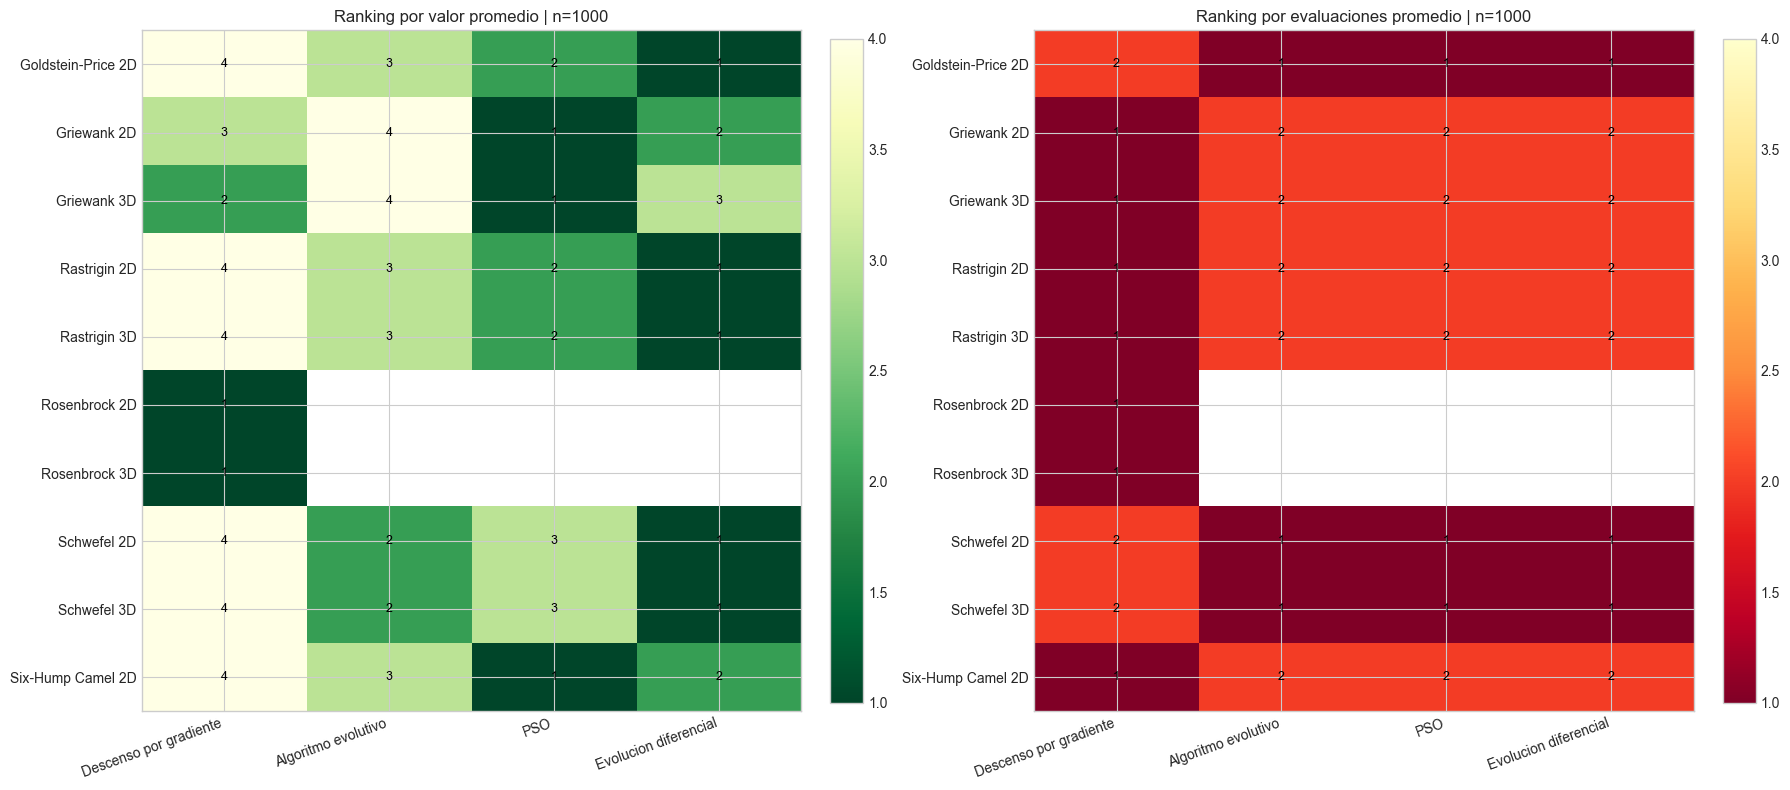

In [223]:
ranking_valor = comparacion_n.copy()
ranking_valor["ranking_valor"] = ranking_valor.groupby("caso")["promedio_valor"].rank(method="dense")
heatmap_valor = (
    ranking_valor.pivot(index="caso", columns="nombre_metodo", values="ranking_valor")
    .reindex(columns=METODOS_ORDEN)
)

ranking_eval = comparacion_n.copy()
ranking_eval["ranking_eval"] = ranking_eval.groupby("caso")["promedio_evaluaciones"].rank(method="dense")
heatmap_eval = (
    ranking_eval.pivot(index="caso", columns="nombre_metodo", values="ranking_eval")
    .reindex(columns=METODOS_ORDEN)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

im1 = axes[0].imshow(heatmap_valor.values, aspect="auto", cmap="YlGn_r", vmin=1, vmax=len(METODOS_ORDEN))
axes[0].set_title(f"Ranking por valor promedio | n={N_OBJETIVO}")
axes[0].set_xticks(range(len(heatmap_valor.columns)))
axes[0].set_xticklabels(heatmap_valor.columns, rotation=20, ha="right")
axes[0].set_yticks(range(len(heatmap_valor.index)))
axes[0].set_yticklabels(heatmap_valor.index)

im2 = axes[1].imshow(heatmap_eval.values, aspect="auto", cmap="YlOrRd_r", vmin=1, vmax=len(METODOS_ORDEN))
axes[1].set_title(f"Ranking por evaluaciones promedio | n={N_OBJETIVO}")
axes[1].set_xticks(range(len(heatmap_eval.columns)))
axes[1].set_xticklabels(heatmap_eval.columns, rotation=20, ha="right")
axes[1].set_yticks(range(len(heatmap_eval.index)))
axes[1].set_yticklabels(heatmap_eval.index)

for ax, data in zip(axes, [heatmap_valor, heatmap_eval]):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, int(value), ha="center", va="center", color="black", fontsize=9)

fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"heatmap_ranking_n{N_OBJETIVO}.png", dpi=200, bbox_inches="tight")
plt.show()

## Convergencia de Rosenbrock segun n

En esta grafica, el eje `x` muestra `n = 100, 500, 1000` y el eje `y` muestra la `mediana_valor` a la que converge cada metodo.

Primero lo dejamos para `Rosenbrock`, comparando `Descenso por gradiente`, `Algoritmo evolutivo` y `PSO`.

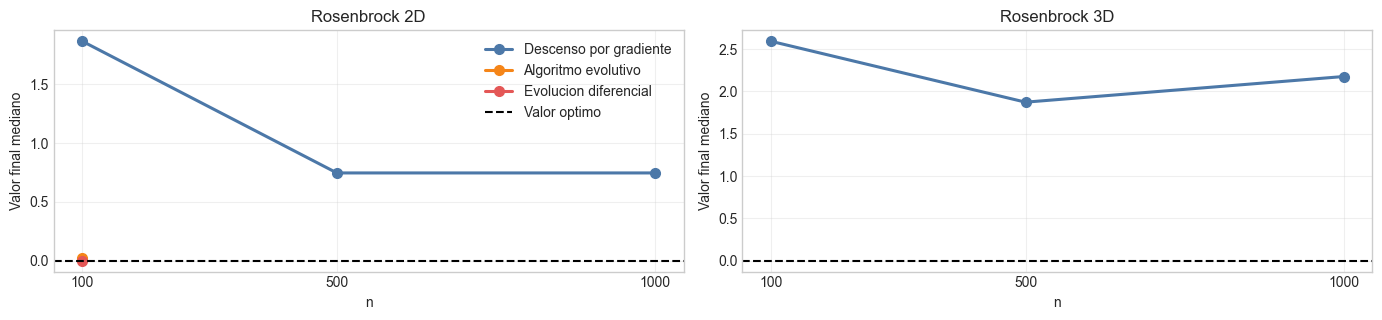

In [224]:
graficar_lineas_por_n('Rosenbrock')


## Mismo grafico para otra funcion

Esta celda sirve para probar la misma visualizacion con otra funcion. Solo cambia el valor de `FUNCION_OBJETIVO`.

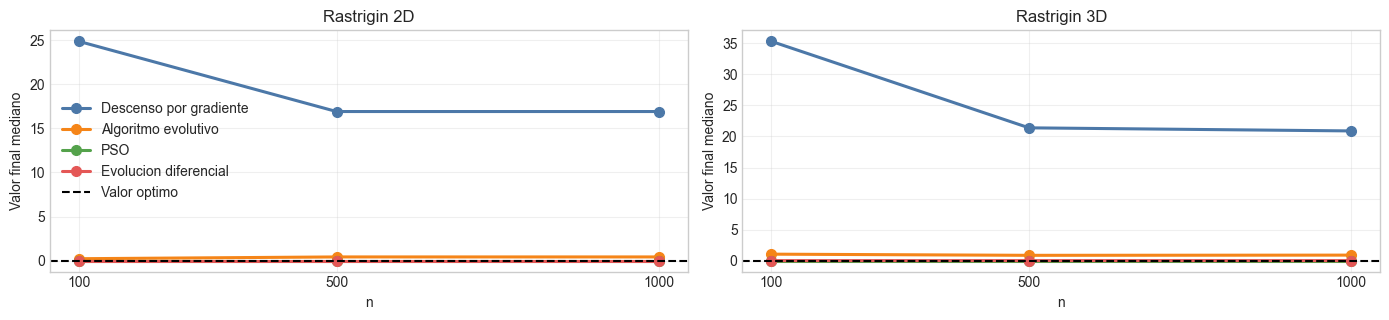

In [225]:
FUNCION_OBJETIVO = 'Rastrigin'
graficar_lineas_por_n(FUNCION_OBJETIVO)


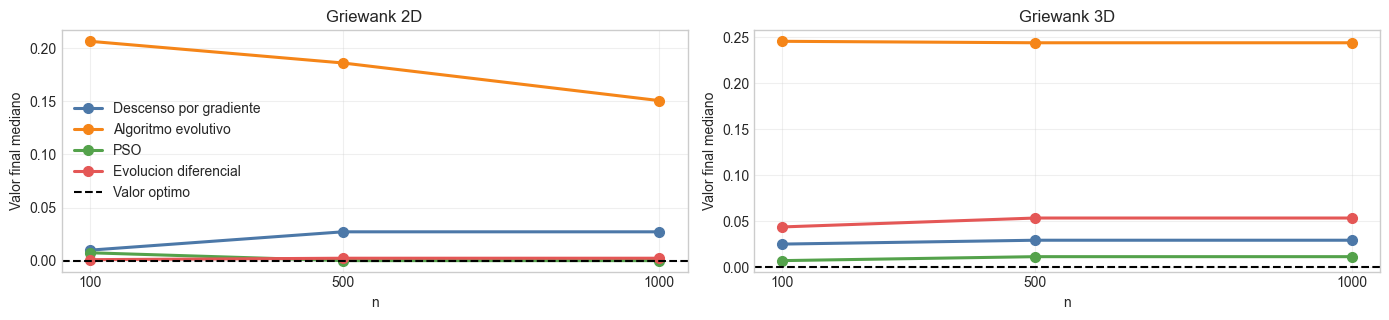

In [226]:
FUNCION_OBJETIVO = 'Griewank'
graficar_lineas_por_n(FUNCION_OBJETIVO)


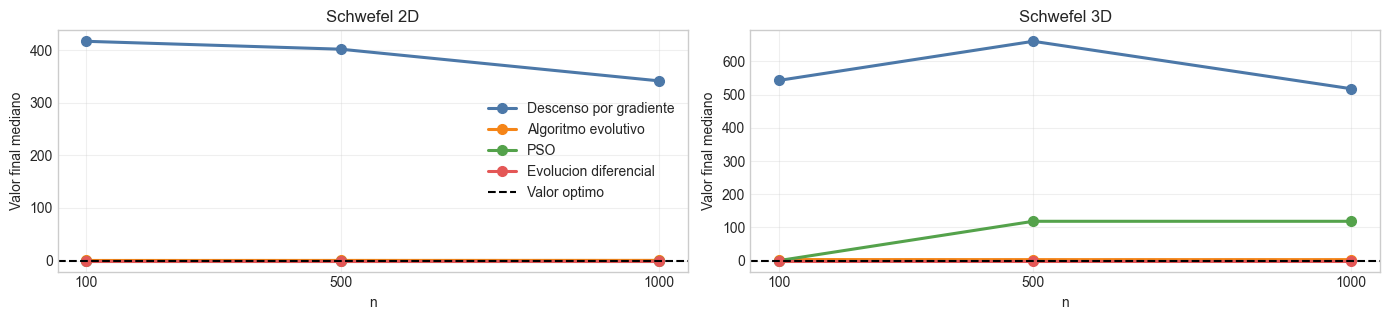

In [227]:
FUNCION_OBJETIVO = 'Schwefel'
graficar_lineas_por_n(FUNCION_OBJETIVO)


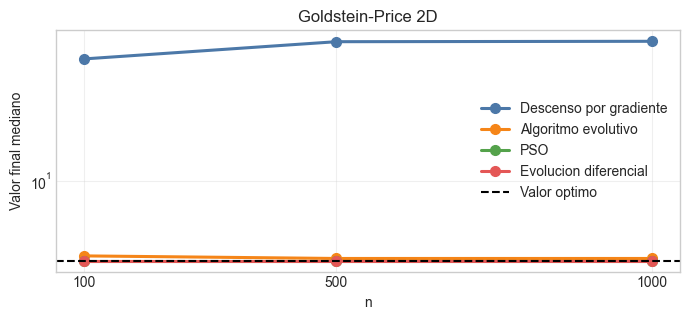

In [228]:
FUNCION_OBJETIVO = 'Goldstein-Price'
graficar_lineas_por_n(FUNCION_OBJETIVO)


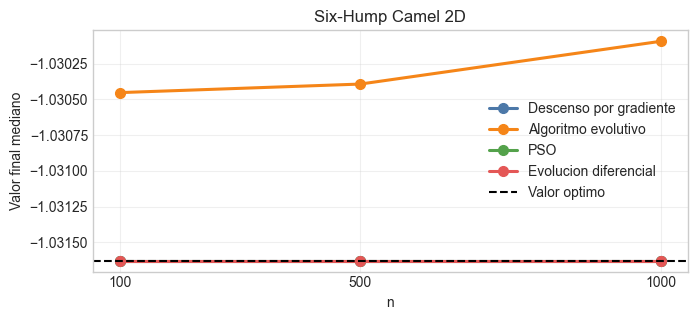

In [229]:
FUNCION_OBJETIVO = 'Six-Hump Camel'
graficar_lineas_por_n(FUNCION_OBJETIVO)


## Barras 2D vs 3D por metodo

Esta visualizacion usa `promedio_valor` para un `n` fijo, y compara los metodos dentro de `2D` y `3D` en paneles separados.

In [230]:
def graficar_barras_2d_3d(funcion_objetivo: str, n_objetivo: int | None = None, guardar: bool = True) -> None:
    n_valor = N_OBJETIVO if n_objetivo is None else n_objetivo
    df_base = comparacion_df[comparacion_df['n_corridas'] == n_valor].copy()

    casos_funcion = [
        caso
        for caso in df_base['caso'].drop_duplicates()
        if caso.startswith(funcion_objetivo + ' ')
    ]

    if not casos_funcion:
        print(f'No se encontraron casos para {funcion_objetivo} con n={n_valor}.')
        return

    casos_funcion = sorted(casos_funcion, key=lambda caso: int(caso.split()[-1].replace('D', '')))
    fig, axes = plt.subplots(1, len(casos_funcion), figsize=(6 * len(casos_funcion), 3.6), sharey=False)
    if len(casos_funcion) == 1:
        axes = [axes]

    for ax, caso in zip(axes, casos_funcion):
        df_case = df_base[df_base['caso'] == caso].copy()
        df_case['nombre_metodo'] = pd.Categorical(df_case['nombre_metodo'], categories=METODOS_ORDEN, ordered=True)
        df_case = df_case.sort_values('nombre_metodo')

        colores = [COLORES_METODOS.get(str(metodo), '#999999') for metodo in df_case['nombre_metodo']]
        ax.bar(df_case['nombre_metodo'].astype(str), df_case['mediana_valor'], color=colores)
        ax.set_title(f'{caso} | n={n_valor}')
        ax.set_xlabel('Metodo')
        ax.set_ylabel('Valor promedio mediano')
        ax.set_yscale('log')
        ax.tick_params(axis='x', rotation=20)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    if guardar:
        output_name = funcion_objetivo.lower().replace('-', '_').replace(' ', '_')
        plt.savefig(OUTPUT_DIR / f'{output_name}_barras_2d_3d_n{n_valor}.png', dpi=200, bbox_inches='tight')

    plt.show()

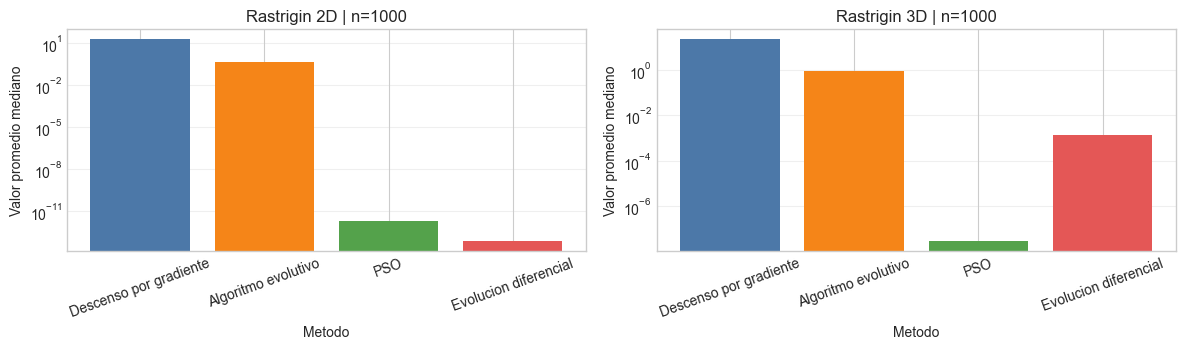

In [231]:
FUNCION_OBJETIVO_BARRAS = 'Rastrigin'
graficar_barras_2d_3d(FUNCION_OBJETIVO_BARRAS)

In [232]:
display(Markdown("### Archivos generados"))
pd.DataFrame({"archivo": sorted(path.name for path in OUTPUT_DIR.iterdir())})

### Archivos generados

,archivo
0,goldstein_price_lineas_por_n.png
1,griewank_lineas_por_n.png
2,heatmap_ranking_n1000.png
3,rastrigin_barras_2d_3d_n1000.png
4,rastrigin_lineas_por_n.png
5,rosenbrock_lineas_por_n.png
6,rosenbrock_resumen_n1000.png
7,schwefel_lineas_por_n.png
8,six_hump_camel_lineas_por_n.png
9,tabla_goldstein_price_2d_n1000.csv
